In [35]:
import pandas as pd
df = pd.read_excel("Messy_Supply_Chain_Dataset.xlsx")
print(df)

      Order_ID  Order_Date   Ship_Date         Supplier   Warehouse  \
0     ORD00001         NaN  2025-07-11  Alpha Logistics  Chennai_WH   
1     ORD00002  2024-06-09  2024-06-22  Eastern Traders     Pune_WH   
2     ORD00003  2025-06-30  2025-07-14      QuickSupply  Chennai_WH   
3     ORD00004  2025-01-31  2025-02-05   Global Freight     Pune_WH   
4     ORD00005  2025-04-22  2025-05-24   Global Freight   Mumbai_WH   
...        ...         ...         ...              ...         ...   
1205  ORD00006  2024-05-19  2024-06-15      QuickSupply   Mumbai_WH   
1206  ORD00007  2024-08-22  2024-09-24  Eastern Traders   Mumbai_WH   
1207  ORD00008         NaN  2025-04-11        Nexus SCM   Mumbai_WH   
1208  ORD00009  2025-06-10  2025-06-27        Nexus SCM     Pune_WH   
1209  ORD00010  2024-03-01  2024-03-06        Nexus SCM  Chennai_WH   

     Product_Category       SKU  Units_Ordered  Units_Received  Unit_Cost  \
0          Automotive  SKU-3058           1272            1134     424

In [2]:
#Quick Inspection
df.head()


,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status
0,ORD00001,NaN,2025-07-11,Alpha Logistics,Chennai_WH,Automotive,SKU-3058,1272,1134,424.24,31,4753,Road,South,Pending
1,ORD00002,2024-06-09,2024-06-22,Eastern Traders,Pune_WH,Automotive,SKU-8122,1058,1042,326.51,13,2840,Sea,West,Delivered
2,ORD00003,2025-06-30,2025-07-14,QuickSupply,Chennai_WH,Automotive,SKU-6642,275,195,282.40,14,5637,Sea,West,Delayed
3,ORD00004,2025-01-31,2025-02-05,Global Freight,Pune_WH,Packaging,SKU-6773,1321,1233,202.07,5,294,Air,North,Cancelled
4,ORD00005,2025-04-22,2025-05-24,Global Freight,Mumbai_WH,Consumer Goods,SKU-2059,86,0,475.04,32,5473,Road,East,Delivered


In [4]:
#Dataset Shape
df.shape

(1210, 15)

In [5]:
#Data Type
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1210 non-null   object 
 1   Order_Date        1196 non-null   object 
 2   Ship_Date         1210 non-null   object 
 3   Supplier          1210 non-null   object 
 4   Warehouse         1210 non-null   object 
 5   Product_Category  1210 non-null   object 
 6   SKU               1210 non-null   object 
 7   Units_Ordered     1210 non-null   int64  
 8   Units_Received    1210 non-null   int64  
 9   Unit_Cost         1200 non-null   float64
 10  Lead_Time_Days    1210 non-null   int64  
 11  Inventory_Level   1210 non-null   int64  
 12  Transport_Mode    1210 non-null   object 
 13  Region            1210 non-null   object 
 14  Order_Status      1210 non-null   object 
dtypes: float64(1), int64(4), object(10)
memory usage: 141.9+ KB


In [ ]:
#Data Quality Assessment

In [6]:
#missing value
df.isnull().sum()


Order_ID             0
Order_Date          14
Ship_Date            0
Supplier             0
Warehouse            0
Product_Category     0
SKU                  0
Units_Ordered        0
Units_Received       0
Unit_Cost           10
Lead_Time_Days       0
Inventory_Level      0
Transport_Mode       0
Region               0
Order_Status         0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(10)

In [21]:
duplicates = df[df.duplicated()]
duplicates.head()

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status
1200,ORD00001,NaN,2025-07-11,Alpha Logistics,Chennai_WH,Automotive,SKU-3058,1272,1134,424.24,31,4753,Road,South,Pending
1201,ORD00002,2024-06-09,2024-06-22,Eastern Traders,Pune_WH,Automotive,SKU-8122,1058,1042,326.51,13,2840,Sea,West,Delivered
1202,ORD00003,2025-06-30,2025-07-14,QuickSupply,Chennai_WH,Automotive,SKU-6642,275,195,282.40,14,5637,Sea,West,Delayed
1203,ORD00004,2025-01-31,2025-02-05,Global Freight,Pune_WH,Packaging,SKU-6773,1321,1233,202.07,5,294,Air,North,Cancelled
1204,ORD00005,2025-04-22,2025-05-24,Global Freight,Mumbai_WH,Consumer Goods,SKU-2059,86,0,475.04,32,5473,Road,East,Delivered


In [31]:
#Check Unique Values
df['Region'].unique()

array(['South', 'West', 'North', 'East'], dtype=object)

In [ ]:
#data cleaning

In [24]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'],errors='coerce')

In [25]:
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'],errors='coerce')

In [26]:
df[df['Order_Date'].isnull()]

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status
0,ORD00001,NaT,2025-07-11,Alpha Logistics,Chennai_WH,Automotive,SKU-3058,1272,1134,424.24,31,4753,Road,South,Pending
7,ORD00008,NaT,2025-04-11,Nexus SCM,Mumbai_WH,Electronics,SKU-7596,1332,1212,215.58,32,5124,Air,West,Delivered
14,ORD00015,NaT,2024-05-12,Alpha Logistics,Pune_WH,Consumer Goods,SKU-5363,1980,1848,268.10,4,1748,Sea,East,Pending
21,ORD00022,NaT,2025-04-16,Nexus SCM,Delhi_WH,Packaging,SKU-9966,724,653,244.56,6,797,Rail,North,Delivered
28,ORD00029,NaT,2024-07-29,Alpha Logistics,Pune_WH,Packaging,SKU-3949,1726,1588,487.64,17,9678,Sea,west,Cancelled
35,ORD00036,NaT,2024-02-12,Alpha Logistics,Pune_WH,Consumer Goods,SKU-3446,-23,780,223.65,7,4955,Air,West,Pending
42,ORD00043,NaT,2024-09-25,Nexus SCM,Mumbai_WH,Automotive,SKU-8415,1182,1126,451.36,35,6761,Sea,West,Delayed
49,ORD00050,NaT,2024-08-12,Alpha Logistics,Delhi_WH,Consumer Goods,SKU-3218,481,449,93.84,26,6899,Road,West,Delayed
56,ORD00057,NaT,2024-05-29,QuickSupply,Chennai_WH,Consumer Goods,SKU-2062,1838,1699,416.07,22,6269,Road,East,Delivered
63,ORD00064,NaT,2025-05-01,Eastern Traders,Delhi_WH,Packaging,SKU-6837,1805,1687,47.04,18,9411,Sea,West,Delivered


In [ ]:
#Remove Duplicates

In [29]:
df.duplicated().sum()

np.int64(0)

In [36]:
df = df.drop_duplicates().copy()

In [37]:
df['Region'] = (df['Region'].str.strip().str.title())

In [38]:
df['Supplier'] = (df['Supplier'].str.strip())

In [39]:
df['Warehouse'] = (
    df['Warehouse']
    .str.strip()
)

In [40]:
df['Unit_Cost'].unique()

array([424.24, 326.51, 282.4 , ..., 311.65, 445.42, 261.82], shape=(1184,))

In [43]:
df['Unit_Cost'] = pd.to_numeric(df['Unit_Cost'],
                errors='coerce')

In [44]:
df['Unit_Cost'].isnull().sum()

np.int64(10)

In [45]:
df['Unit_Cost'].unique()            

array([424.24, 326.51, 282.4 , ..., 311.65, 445.42, 261.82], shape=(1184,))

In [46]:
df[df['Units_Ordered'] < 0]

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status
13,ORD00014,2025-11-09,2025-12-05,Global Freight,Delhi_WH,Electronics,SKU-5294,-2,89,90.34,26,7874,Rail,West,Delayed
24,ORD00025,2025-06-28,2025-07-26,Alpha Logistics,Mumbai_WH,Consumer Goods,SKU-6197,-46,1459,399.65,28,3903,Road,East,Pending
35,ORD00036,NaN,2024-02-12,Alpha Logistics,Pune_WH,Consumer Goods,SKU-3446,-23,780,223.65,7,4955,Air,West,Pending
46,ORD00047,2025-08-28,2025-09-24,Nexus SCM,Pune_WH,Automotive,SKU-2300,-10,1637,188.66,27,3381,Road,North,Delayed
57,ORD00058,2024-01-07,2024-01-07,Global Freight,Chennai_WH,Packaging,SKU-3118,-10,1398,NaN,8,6978,Road,West,Delayed
68,ORD00069,2025-06-18,2025-07-01,Eastern Traders,Mumbai_WH,Electronics,SKU-6167,-41,385,36.55,13,155,Rail,East,Cancelled
79,ORD00080,2025-08-22,2025-08-27,Global Freight,Delhi_WH,Packaging,SKU-4205,-50,329,45.13,5,2586,Air,West,Cancelled
90,ORD00091,2024-06-05,2024-06-13,QuickSupply,Chennai_WH,Packaging,SKU-4543,-30,1233,381.34,8,7836,Air,South,Delivered
101,ORD00102,2024-12-28,2025-01-12,Global Freight,Mumbai_WH,Electronics,SKU-7500,-4,905,446.19,15,4040,Air,South,Pending
112,ORD00113,2025-01-18,2025-02-19,Global Freight,Delhi_WH,Medical,SKU-4642,-17,1492,158.31,32,3874,Road,East,Pending


In [47]:
df = df[df['Units_Ordered'] >= 0]

In [48]:
df[df['Units_Received'] < 0]

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status


In [ ]:
#Missing Values Treatment

In [49]:
df['Unit_Cost'].fillna(df['Unit_Cost'].median(),inplace = True)

In [ ]:
#removing missing Date column

In [50]:
df = df.dropna(subset = ['Order_Date'])

In [52]:
#Business Rule Checks
#Ship Date Before Order Date?
df[df['Ship_Date']<df['Order_Date']]

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status


In [53]:
df[
    df['Units_Received'] >
    df['Units_Ordered']
]

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status


In [54]:
df[df['Lead_Time_Days'] < 0]

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status


In [ ]:
#Outlier Detection

In [58]:
df['Procurement_Cost'] = df['Unit_Cost']*df['Units_Received']

In [63]:
df

,Order_ID,Order_Date,Ship_Date,Supplier,Warehouse,Product_Category,SKU,Units_Ordered,Units_Received,Unit_Cost,Lead_Time_Days,Inventory_Level,Transport_Mode,Region,Order_Status,Procurement_Cost
1,ORD00002,2024-06-09,2024-06-22,Eastern Traders,Pune_WH,Automotive,SKU-8122,1058,1042,326.51,13,2840,Sea,West,Delivered,340223.42
2,ORD00003,2025-06-30,2025-07-14,QuickSupply,Chennai_WH,Automotive,SKU-6642,275,195,282.40,14,5637,Sea,West,Delayed,55068.00
3,ORD00004,2025-01-31,2025-02-05,Global Freight,Pune_WH,Packaging,SKU-6773,1321,1233,202.07,5,294,Air,North,Cancelled,249152.31
4,ORD00005,2025-04-22,2025-05-24,Global Freight,Mumbai_WH,Consumer Goods,SKU-2059,86,0,475.04,32,5473,Road,East,Delivered,0.00
5,ORD00006,2024-05-19,2024-06-15,QuickSupply,Mumbai_WH,Automotive,SKU-9812,122,40,35.42,27,84,Rail,East,Pending,1416.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD01196,2024-08-29,2024-09-25,Nexus SCM,Chennai_WH,Medical,SKU-9189,613,499,154.56,27,9403,Air,East,Cancelled,77125.44
1196,ORD01197,2024-08-17,2024-09-21,Eastern Traders,Delhi_WH,Consumer Goods,SKU-1508,531,424,311.65,35,923,Sea,West,Delayed,132139.60
1197,ORD01198,2025-08-08,2025-08-24,Nexus SCM,Delhi_WH,Consumer Goods,SKU-5040,92,47,445.42,16,3173,Road,West,Delivered,20934.74
1198,ORD01199,2025-11-20,2025-12-01,QuickSupply,Chennai_WH,Medical,SKU-7066,415,274,261.82,11,7085,Sea,East,Cancelled,71738.68


In [62]:
df = df.drop('Procure_cost',axis=1)

In [64]:
df['Procurement_Cost'].describe()

count      1179.000000
mean     237303.390568
std      211672.653774
min           0.000000
25%       62948.650000
50%      176713.240000
75%      360978.740000
max      906071.200000
Name: Procurement_Cost, dtype: float64

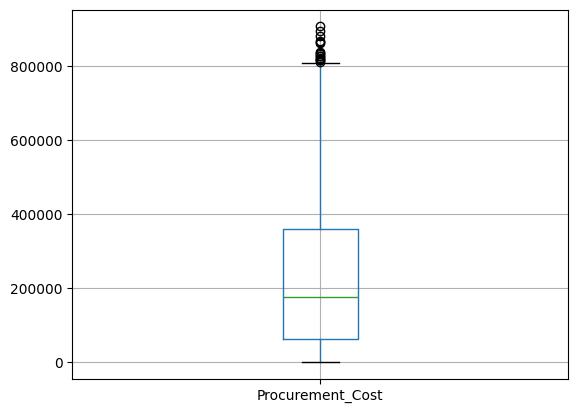

In [66]:
import matplotlib.pyplot as plt
df.boxplot(column='Procurement_Cost')
plt.show()

In [ ]:
#Create New Features

In [68]:
df['Fill_Rate'] = (df['Units_Received']/df['Units_Ordered'])*100

In [71]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1179 entries, 1 to 1199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1179 non-null   object 
 1   Order_Date        1179 non-null   object 
 2   Ship_Date         1179 non-null   object 
 3   Supplier          1179 non-null   object 
 4   Warehouse         1179 non-null   object 
 5   Product_Category  1179 non-null   object 
 6   SKU               1179 non-null   object 
 7   Units_Ordered     1179 non-null   int64  
 8   Units_Received    1179 non-null   int64  
 9   Unit_Cost         1179 non-null   float64
 10  Lead_Time_Days    1179 non-null   int64  
 11  Inventory_Level   1179 non-null   int64  
 12  Transport_Mode    1179 non-null   object 
 13  Region            1179 non-null   object 
 14  Order_Status      1179 non-null   object 
 15  Procurement_Cost  1179 non-null   float64
 16  Fill_Rate         1179 non-null   float64
dtype

Order_ID            0
Order_Date          0
Ship_Date           0
Supplier            0
Warehouse           0
Product_Category    0
SKU                 0
Units_Ordered       0
Units_Received      0
Unit_Cost           0
Lead_Time_Days      0
Inventory_Level     0
Transport_Mode      0
Region              0
Order_Status        0
Procurement_Cost    0
Fill_Rate           0
dtype: int64

In [73]:
df.to_csv( "clean_supply_chain.csv",index=False )